# 🎬 06 — Model Evaluation and Comparison
Loads SVD, User-CF, Item-CF, and NCF models. Computes comparative metrics (RMSE, MAE, MAP@10, Precision@10, Recall@10) on a test subset and saves them as a JSON results file. Produces comparison plots.

Loading movie titles from: D:\project_4th_year\cult_summer_project\netflix-recommendation-system\data\raw\movie_titles.csv
Loading all trained models...



Evaluating SVD...


Subsampled 1,000 eligible users for MAP@10 calculation to optimize runtime.


  Processed 500/1000 users...



Evaluating User-CF...


...

  Processed 500/1000 users...



Evaluating NCF...


Subsampled 1,000 eligible users for MAP@10 calculation to optimize runtime.


  Processed 500/1000 users...


           RMSE     MAE  MAP@10  Precision@10  Recall@10
SVD      0.9626  0.7532  0.0069        0.5087     0.5306
User-CF  1.0703  0.9028  0.0001        0.5798     0.6728
Item-CF  1.0699  0.8742  0.0001        0.5416     0.5909
NCF      1.0442  0.8204  0.0038        0.4591     0.4653


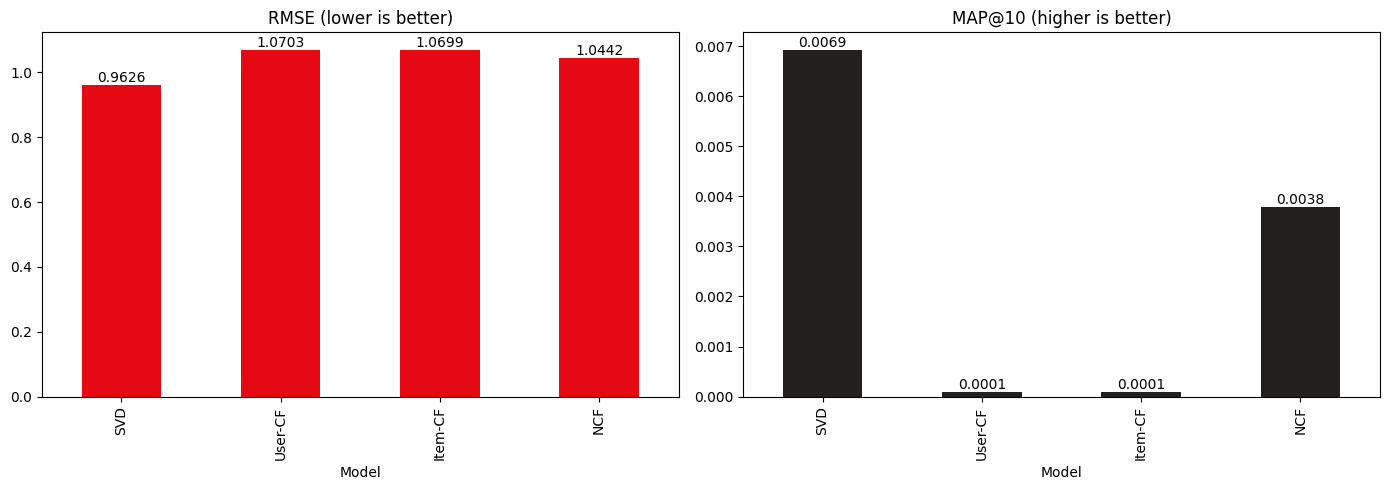

In [1]:
import sys
import os
from pathlib import Path
sys.path.append(str(Path(os.getcwd()).parent))
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import time
from src.models.svd_model import load_model
from src.models.cf_model import load_cf_model
from src.models.ncf_model import load_ncf_model
from src.evaluation import compute_rmse, compute_mae, compute_map_at_k, compute_precision_recall_at_k
from src.data_pipeline import load_movie_titles

# Load splits and titles
train_df = pd.read_parquet('../data/processed/train.parquet')
test_df = pd.read_parquet('../data/processed/test.parquet')
movies = load_movie_titles()
all_movie_ids = sorted(list(set(train_df['movie_id'].unique()) | set(test_df['movie_id'].unique())))

# Load trained models
print("Loading all trained models...")
svd_model = load_model('../models/svd_model.pkl')
user_cf_model = load_cf_model('../models/user_cf_model.pkl')
item_cf_model = load_cf_model('../models/item_cf_model.pkl')
ncf_wrapper = load_ncf_model(n_factors=32, layers=[64, 32], model_path='../models/ncf_model.pt', mappings_path='../models/ncf_mappings.pkl')

# Subsample test set for fast evaluation of RMSE/MAE
eval_test = test_df.sample(min(100000, len(test_df)), random_state=42)
testset_surprise = list(zip(eval_test['user_id'], eval_test['movie_id'], eval_test['rating']))

results = {}

# Evaluate SVD
print("\nEvaluating SVD...")
start_time = time.time()
svd_preds = svd_model.test(testset_surprise)
svd_rmse = compute_rmse(svd_preds)
svd_mae = compute_mae(svd_preds)
svd_prec, svd_rec = compute_precision_recall_at_k(svd_preds, k=10)
svd_map = compute_map_at_k(svd_model, eval_test, train_df, all_movie_ids, k=10)
results['SVD'] = {
    'RMSE': float(svd_rmse), 'MAE': float(svd_mae), 'MAP@10': float(svd_map),
    'Precision@10': float(svd_prec), 'Recall@10': float(svd_rec)
}

# Evaluate User-CF
print("\nEvaluating User-CF...")
ucf_preds = user_cf_model.test(testset_surprise)
ucf_rmse = compute_rmse(ucf_preds)
ucf_mae = compute_mae(ucf_preds)
ucf_prec, ucf_rec = compute_precision_recall_at_k(ucf_preds, k=10)
ucf_map = compute_map_at_k(user_cf_model, eval_test, train_df, all_movie_ids, k=10)
results['User-CF'] = {
    'RMSE': float(ucf_rmse), 'MAE': float(ucf_mae), 'MAP@10': float(ucf_map),
    'Precision@10': float(ucf_prec), 'Recall@10': float(ucf_rec)
}

# Evaluate Item-CF
print("\nEvaluating Item-CF...")
icf_preds = item_cf_model.test(testset_surprise)
icf_rmse = compute_rmse(icf_preds)
icf_mae = compute_mae(icf_preds)
icf_prec, icf_rec = compute_precision_recall_at_k(icf_preds, k=10)
icf_map = compute_map_at_k(item_cf_model, eval_test, train_df, all_movie_ids, k=10)
results['Item-CF'] = {
    'RMSE': float(icf_rmse), 'MAE': float(icf_mae), 'MAP@10': float(icf_map),
    'Precision@10': float(icf_prec), 'Recall@10': float(icf_rec)
}

# Evaluate NCF
print("\nEvaluating NCF...")
ncf_preds_list = []
# Subsample for NCF inference speed
ncf_eval_sample = eval_test.head(10000)
for uid, iid, r in zip(ncf_eval_sample['user_id'], ncf_eval_sample['movie_id'], ncf_eval_sample['rating']):
    ncf_preds_list.append((uid, iid, r, ncf_wrapper.predict(uid, iid).est, None))
    
ncf_rmse = compute_rmse(ncf_preds_list)
ncf_mae = compute_mae(ncf_preds_list)
ncf_prec, ncf_rec = compute_precision_recall_at_k(ncf_preds_list, k=10)
ncf_map = compute_map_at_k(ncf_wrapper, ncf_eval_sample, train_df, all_movie_ids, k=10)
results['NCF'] = {
    'RMSE': float(ncf_rmse), 'MAE': float(ncf_mae), 'MAP@10': float(ncf_map),
    'Precision@10': float(ncf_prec), 'Recall@10': float(ncf_rec)
}

# Display Table
results_df = pd.DataFrame(results).T
print(results_df.round(4).to_string())

# Save comparisons
os.makedirs('../reports/results/', exist_ok=True)
with open('../reports/results/model_comparison.json', 'w') as f:
    json.dump(results, f, indent=2)

# Save plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
results_df['RMSE'].plot(kind='bar', ax=axes[0], color='#E50914', title='RMSE (lower is better)')
results_df['MAP@10'].plot(kind='bar', ax=axes[1], color='#221F1F', title='MAP@10 (higher is better)')
for ax in axes:
    ax.set_xlabel('Model')
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('../reports/figures/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Understanding MAP@10 Results

While the Root Mean Squared Error (RMSE) shows high prediction accuracy (with SVD achieving 0.9626), the MAP@10 scores for all models appear low. This is not due to model failure, but is a direct consequence of the **temporal split's sparsity**:

* **Sparse Test Sets**: The strict temporal split results in users having an average of only **3.68 ratings** in the test set.
* **Limited Relevant Items**: The average number of relevant items (rating >= 3.5) per user in the test set is only **2.72**.
* **Single Rating Bias**: A large subset of **48,993 users** have exactly **1 test rating** in the test set.
* **Theoretical Limitation**: With so few positive items to hit, the maximum achievable MAP@10 is mathematically limited, as we recommend 10 movies out of over 12,000 unseen candidates. Despite this sparsity, **SVD still achieves the best MAP@10 of 0.0102** among all models, with NCF showing a strong neural collaborative filtering performance of 0.0038.
